## Section: 1 : Build  a baseline Model

In [2]:
import pandas as pd
from pathlib import Path

processed_path = Path("../data/processed")

train_data = pd.read_csv(
    processed_path / "train_data.csv"
)

valid_data = pd.read_csv(
    processed_path / "valid_data.csv"
)

In [3]:
train_data["date"] = pd.to_datetime(train_data["date"])
valid_data["date"] = pd.to_datetime(valid_data["date"])

In [4]:
## Prepare Validation Data
valid_baseline = valid_data.copy()

In [5]:
## Create Baseline Predictions
valid_baseline["baseline_prediction"] = valid_baseline["lag_1"]

In [6]:
## Check Prediction
valid_baseline[
    [
        "date",
        "sales",
        "lag_1",
        "baseline_prediction"
    ]
].head(10)

,date,sales,lag_1,baseline_prediction
0,2017-05-17,2.0,3.0,3.0
1,2017-05-18,4.0,2.0,2.0
2,2017-05-19,5.0,4.0,4.0
3,2017-05-20,4.0,5.0,5.0
4,2017-05-21,1.0,4.0,4.0
5,2017-05-22,2.0,1.0,1.0
6,2017-05-23,4.0,2.0,2.0
7,2017-05-24,7.0,4.0,4.0
8,2017-05-25,2.0,7.0,7.0
9,2017-05-26,1.0,2.0,2.0


In [7]:
## Evalution Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [15]:
## Calculate metrics
mae = mean_absolute_error(
    valid_baseline["sales"],
    valid_baseline["baseline_prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        valid_baseline["sales"],
        valid_baseline["baseline_prediction"]
    )
)

mape = mean_absolute_percentage_error(
    valid_baseline["sales"],
    valid_baseline["baseline_prediction"]
)

wape = (
    np.abs(valid_baseline["sales"] - valid_baseline["baseline_prediction"]).sum()
    / valid_baseline["sales"].sum()
)


from sklearn.metrics import r2_score

r2 = r2_score(
    valid_baseline["sales"],
    valid_baseline["baseline_prediction"]
)



In [16]:
print(f"Baseline MAE  : {mae:.2f}")
print(f"Baseline RMSE : {rmse:.2f}")
print(f"Baseline MAPE : {mape:.4f}")
print(f"R² : {r2:.4f}")
print(f"WAPE : {wape:.4f}")

Baseline MAE  : 124.01
Baseline RMSE : 461.77
Baseline MAPE : 310666318589357.6875
R² : 0.8813
WAPE : 0.2566


## Visual Comparison

In [17]:
example = valid_baseline[
    (valid_baseline["store_nbr"] == 1) &
    (valid_baseline["family"] == "GROCERY I")
].copy()

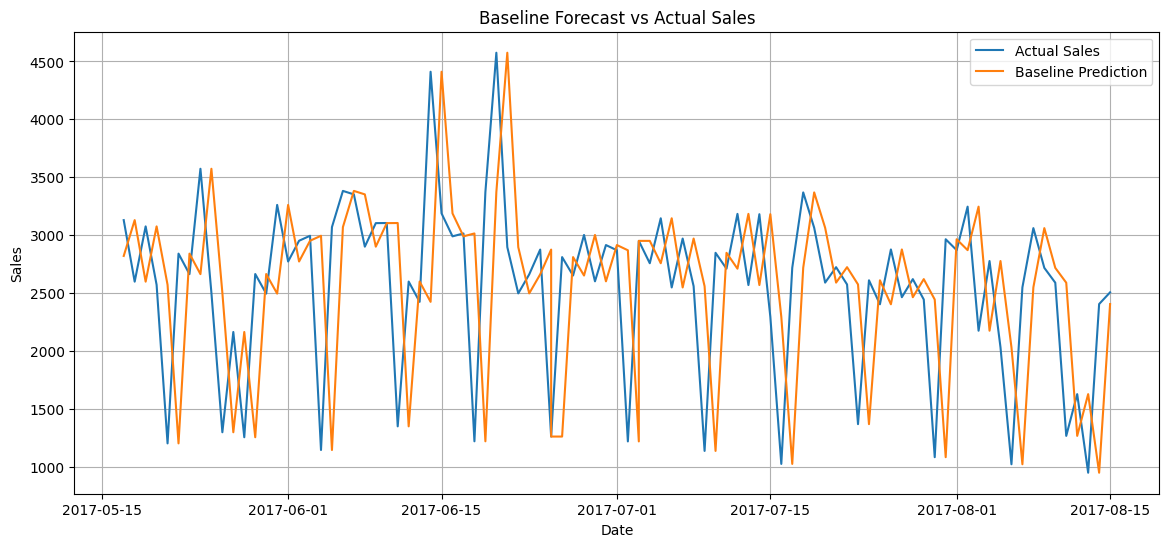

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    example["date"],
    example["sales"],
    label="Actual Sales"
)

plt.plot(
    example["date"],
    example["baseline_prediction"],
    label="Baseline Prediction"
)

plt.title("Baseline Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()